# REXIA – Responsible and Explainable AI
## Projet 2026 – Partie 1 : Données Tabulaires

**Jeu de données :** `RH_dataset.csv`  
**Objectif :** Prédire si un employé va démissionner dans les 6 prochains mois (label 0/1)

## 0. Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../RH_dataset.csv', sep=';')
print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 23857 lignes × 14 colonnes


,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0


---
## 1. Analyse du jeu de données

### 1.1 Informations générales

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  object 
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  object 
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  l

In [3]:
df.describe(include='all')

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
count,23857,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857.000000,23857,23857.000000,23857.000000,23857.000000
unique,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN
top,Production,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Marié(e),NaN,NaN,NaN
freq,10833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10251,NaN,NaN,NaN
mean,NaN,29.460739,7.934986,7.530322,11.632095,20.193947,41.767154,0.720711,1.554554,4168.404032,NaN,0.506853,1361.255858,0.031647
std,NaN,25.497874,7.549982,5.985476,9.218618,9.295469,11.014444,0.448659,0.657887,1657.829824,NaN,0.500299,794.183153,0.175062
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.000000,2134.000000,NaN,0.000000,0.000000,0.000000
25%,NaN,10.590000,3.180000,2.300000,3.800000,11.000000,34.000000,0.000000,1.000000,3197.000000,NaN,0.000000,655.000000,0.000000
50%,NaN,21.219999,5.880000,6.280000,9.870000,26.000000,41.000000,1.000000,1.000000,3629.000000,NaN,1.000000,1371.000000,0.000000
75%,NaN,41.400002,10.340000,11.070000,16.320000,28.000000,49.000000,1.000000,2.000000,4511.000000,NaN,1.000000,2072.000000,0.000000


### 1.2 Valeurs manquantes

In [4]:
missing = df.isnull().sum().rename('nb_manquants')
missing_pct = (df.isnull().mean() * 100).rename('% manquants')
missing_df = pd.concat([missing, missing_pct], axis=1)
print(missing_df[missing_df['nb_manquants'] > 0])
print('\nAucune valeur manquante.' if missing_df['nb_manquants'].sum() == 0 else '')

Empty DataFrame
Columns: [nb_manquants, % manquants]
Index: []

Aucune valeur manquante.


> **Commentaire :** Le jeu de données ne contient aucune valeur manquante. On peut donc passer directement à l'exploration sans étape d'imputation.

### 1.3 Exploration des colonnes

In [5]:
# Colonnes numériques et catégorielles
num_cols = df.select_dtypes(include='number').columns.drop('label', errors='ignore').drop('matricule', errors='ignore').tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Colonnes numériques :', num_cols)
print('Colonnes catégorielles :', cat_cols)

Colonnes numériques : ['Dernière promotion (mois)', 'Dernière augmentation (mois)', 'Début de contrat (années)', 'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent', 'Niveau hiérarchique', 'Salaire (Euros)', 'Véhicule']
Colonnes catégorielles : ["Famille d'emploi", 'Statut marital']


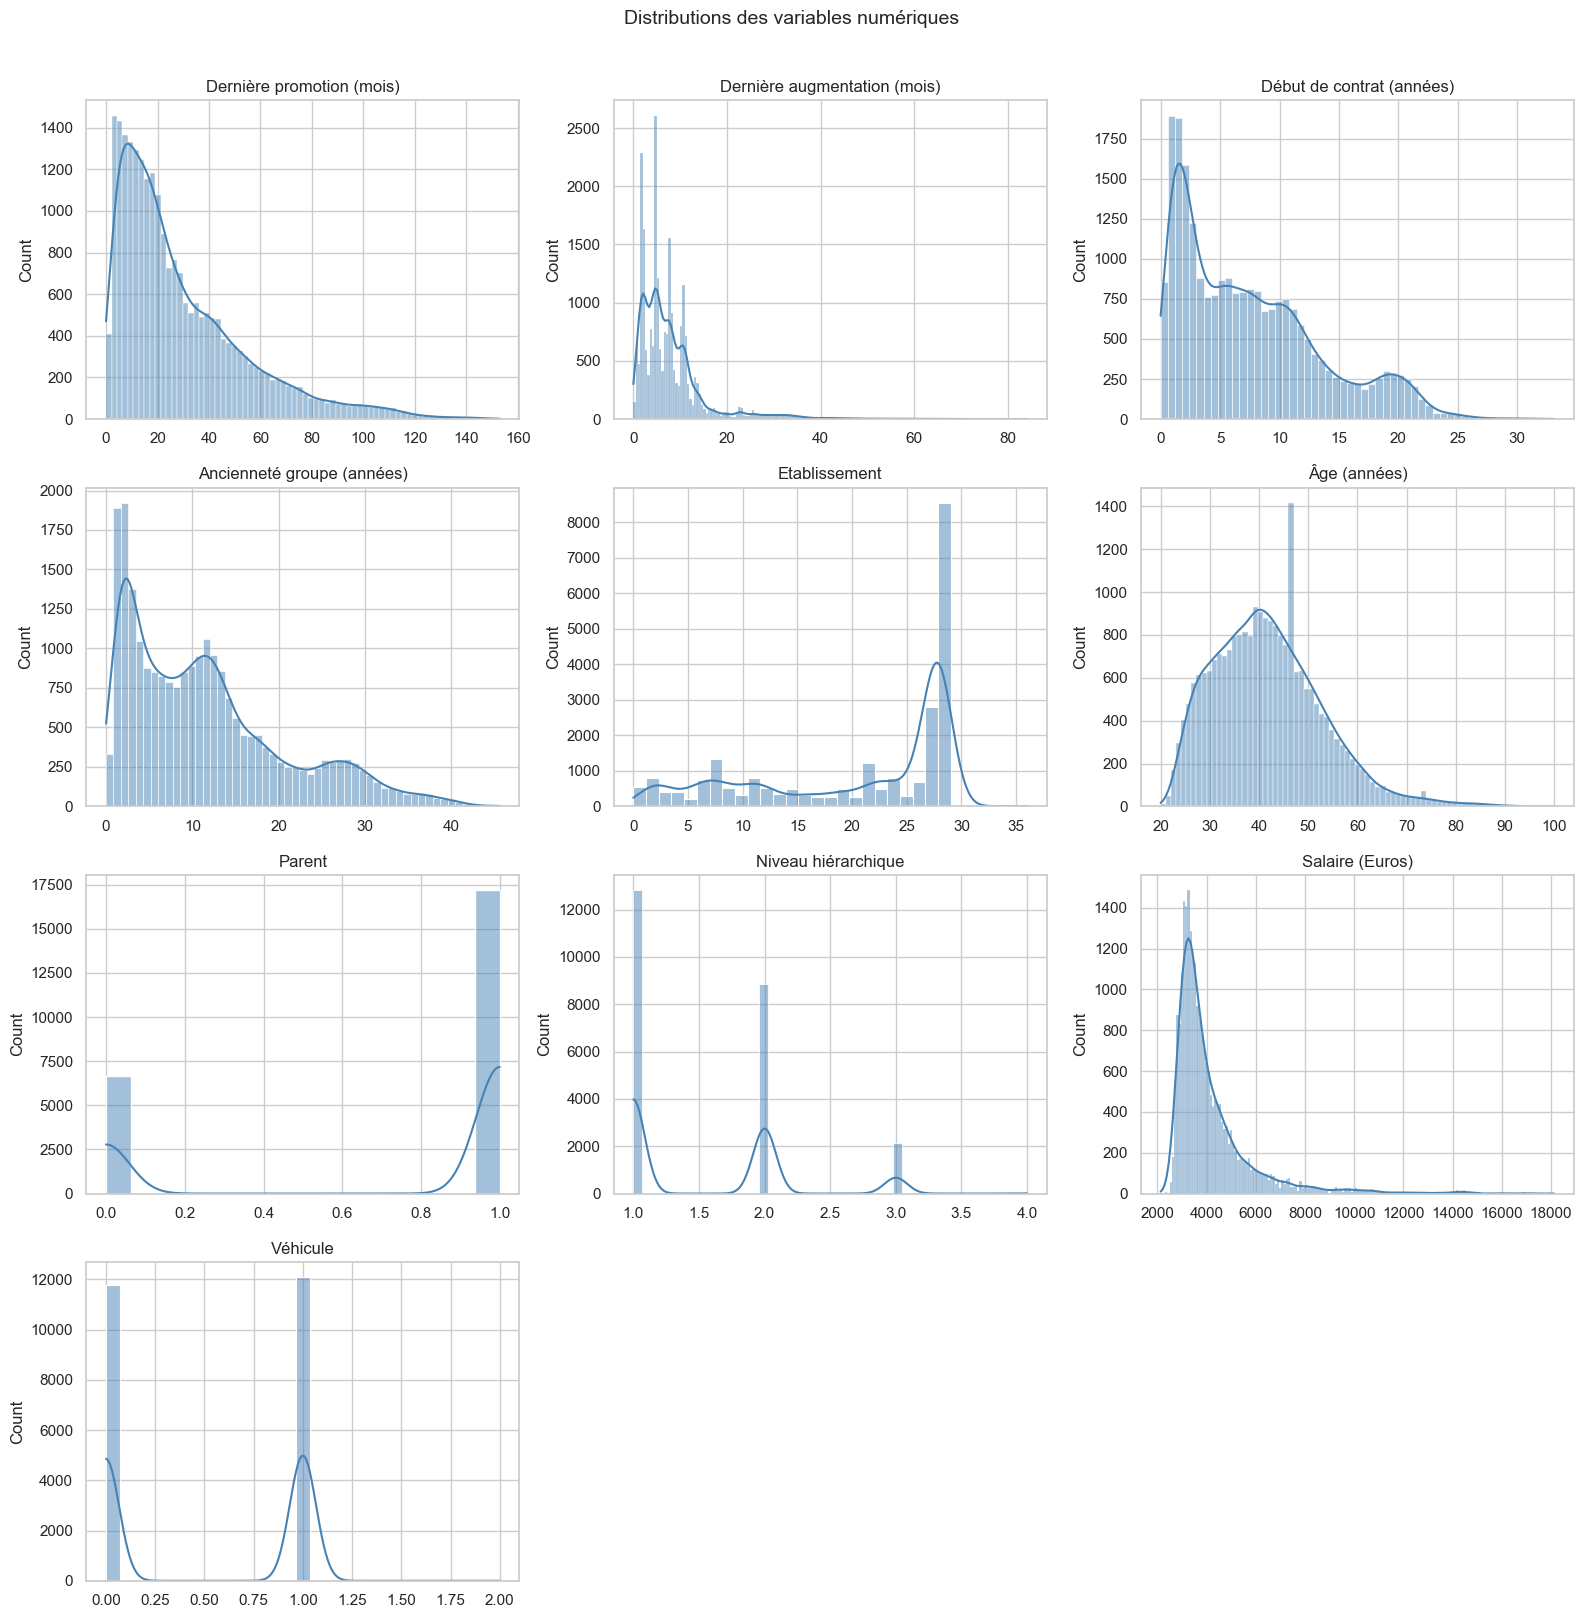

In [6]:
# Distribution des variables numériques
n_cols = len(num_cols)
fig, axes = plt.subplots(nrows=(n_cols + 2) // 3, ncols=3, figsize=(16, 4 * ((n_cols + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des variables numériques', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/xt/dvtp1prj3pg6x4ybk7s2p4t00000gn/T/ipykernel_76432/2241359900.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='muted', ax=ax)


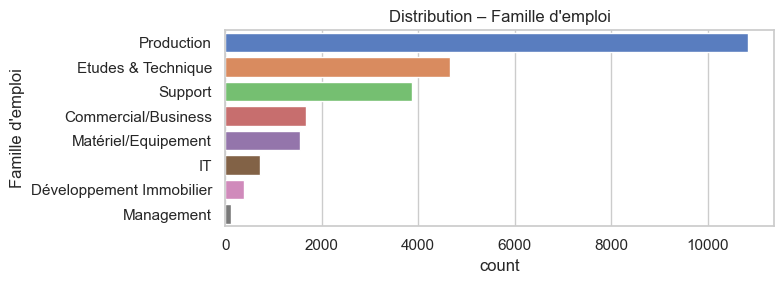

Famille d'emploi
Production                  10833
Etudes & Technique           4668
Support                      3876
Commercial/Business          1682
Matériel/Equipement          1548
IT                            723
Développement Immobilier      395
Management                    132 



/var/folders/xt/dvtp1prj3pg6x4ybk7s2p4t00000gn/T/ipykernel_76432/2241359900.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, palette='muted', ax=ax)


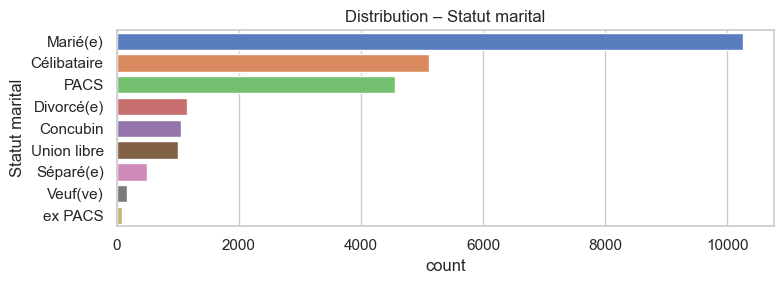

Statut marital
Marié(e)       10251
Célibataire     5111
PACS            4556
Divorcé(e)      1141
Concubin        1053
Union libre     1009
Séparé(e)        488
Veuf(ve)         165
ex PACS           83 



In [7]:
# Distribution des variables catégorielles
for col in cat_cols:
    fig, ax = plt.subplots(figsize=(8, 3))
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, palette='muted', ax=ax)
    ax.set_title(f'Distribution – {col}')
    plt.tight_layout()
    plt.show()
    print(df[col].value_counts().to_string(), '\n')

> **Commentaire :** On observe que les variables numériques présentent des distributions variées. `Dernière promotion (mois)` et `Dernière augmentation (mois)` sont fortement asymétriques à droite, ce qui suggère qu'une majorité d'employés n'ont pas eu de promotion ou d'augmentation récente. `Âge (années)` suit une distribution plus étalée. Côté catégoriel, la variable `Famille d'emploi` est dominée par quelques modalités (ex. Production), tandis que `Statut marital` présente plusieurs modalités dont certaines très peu représentées.

### 1.4 Distribution de la variable cible (label)

/var/folders/xt/dvtp1prj3pg6x4ybk7s2p4t00000gn/T/ipykernel_76432/2021452999.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette=['steelblue', 'tomato'], ax=ax)


Répartition des classes :
       Effectifs     % 
label                  
0          23102  96.84
1            755   3.16


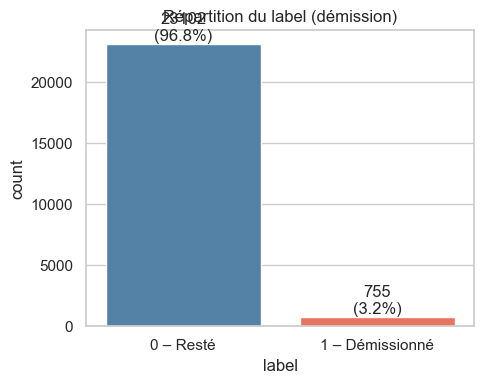

In [8]:
label_counts = df['label'].value_counts()
label_pct = df['label'].value_counts(normalize=True) * 100

print('Répartition des classes :')
print(pd.DataFrame({'Effectifs': label_counts, '% ': label_pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='label', palette=['steelblue', 'tomato'], ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 – Resté', '1 – Démissionné'])
ax.set_title('Répartition du label (démission)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}\n({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

> **Commentaire :** Le jeu de données est déséquilibré : la classe 1 (démission) est nettement minoritaire. Ce déséquilibre est réaliste (peu d'employés démissionnent réellement), mais il devra être pris en compte lors de la modélisation, par exemple via le paramètre `class_weight='balanced'` ou des techniques de rééquilibrage comme SMOTE, pour éviter qu'un modèle n'apprenne à tout prédire comme « non-démission ».

### 1.5 Parcours d'un employé démissionnaire vs. non-démissionnaire

In [9]:
# Sélection d'un exemple par classe
emp_demissionnaire = df[df['label'] == 1].iloc[0]
emp_reste = df[df['label'] == 0].iloc[0]

comparison = pd.DataFrame({
    'Démissionnaire (label=1)': emp_demissionnaire,
    'Non-démissionnaire (label=0)': emp_reste
})
comparison

,Démissionnaire (label=1),Non-démissionnaire (label=0)
Famille d'emploi,Production,Production
Dernière promotion (mois),5.24,8.51
Dernière augmentation (mois),5.1,7.9
Début de contrat (années),1.02,0.91
Ancienneté groupe (années),1.75,0.97
Etablissement,27,27
Âge (années),24,30
Parent,0,1
Niveau hiérarchique,1,1
Salaire (Euros),2641,3199


In [10]:
# Comparaison des moyennes numériques par label
means_by_label = df.groupby('label')[num_cols].mean().T
means_by_label.columns = ['Non-démissionnaire (0)', 'Démissionnaire (1)']
means_by_label['Différence (1-0)'] = means_by_label['Démissionnaire (1)'] - means_by_label['Non-démissionnaire (0)']
means_by_label.style.background_gradient(subset=['Différence (1-0)'], cmap='RdYlGn_r')

,Non-démissionnaire (0),Démissionnaire (1),Différence (1-0)
Dernière promotion (mois),29.644239,23.845894,-5.798345
Dernière augmentation (mois),7.930876,8.060728,0.129852
Début de contrat (années),7.623685,4.673563,-2.950122
Ancienneté groupe (années),11.808123,6.245868,-5.562256
Etablissement,20.234568,18.950993,-1.283575
Âge (années),41.979482,35.270199,-6.709284
Parent,0.728422,0.484768,-0.243654
Niveau hiérarchique,1.561423,1.344371,-0.217052
Salaire (Euros),4185.813220,3635.705960,-550.107259
Véhicule,0.512813,0.324503,-0.188309


/var/folders/xt/dvtp1prj3pg6x4ybk7s2p4t00000gn/T/ipykernel_76432/407389829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, palette=['steelblue', 'tomato'], ax=axes[i])
/var/folders/xt/dvtp1prj3pg6x4ybk7s2p4t00000gn/T/ipykernel_76432/407389829.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Resté (0)', 'Démissionné (1)'])
/var/folders/xt/dvtp1prj3pg6x4ybk7s2p4t00000gn/T/ipykernel_76432/407389829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, palette=['steelblue', 'tomato'], ax=axes[i])
/var/folders/xt/dvtp1prj3pg6x4y

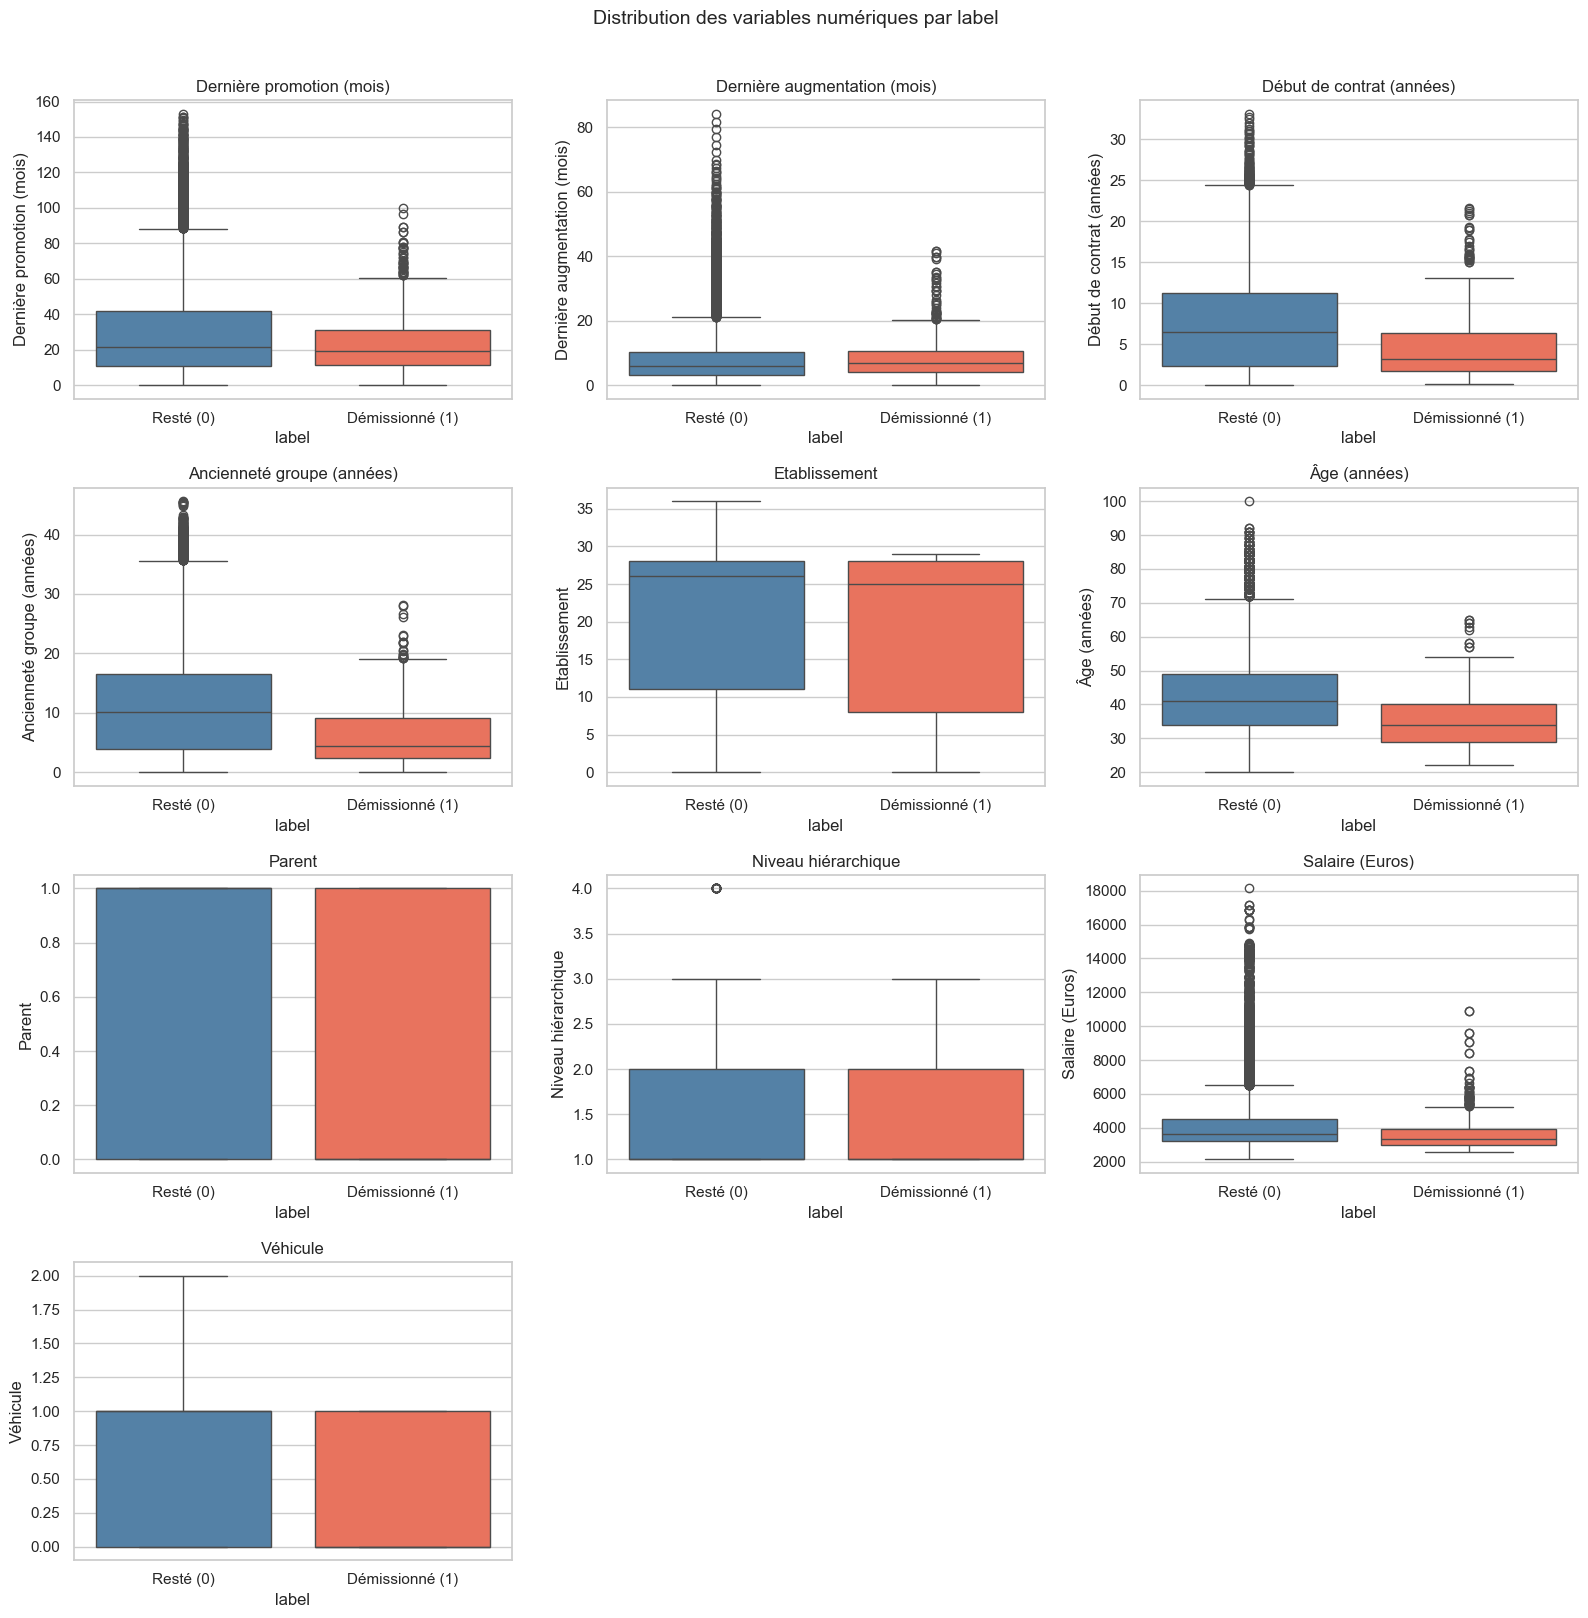

In [11]:
# Boxplots comparatifs
fig, axes = plt.subplots(nrows=(len(num_cols) + 2) // 3, ncols=3,
                          figsize=(16, 4 * ((len(num_cols) + 2) // 3)))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='label', y=col, palette=['steelblue', 'tomato'], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xticklabels(['Resté (0)', 'Démissionné (1)'])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables numériques par label', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

> **Commentaire :** En comparant les deux profils, on constate que l'employé démissionnaire a en général une dernière promotion et une dernière augmentation plus anciennes, un salaire plus faible et une ancienneté moindre. Ces différences, visibles dans les boxplots, laissent penser que le manque de progression salariale et hiérarchique est un facteur associé à la démission. Ces variables seront donc des candidats importants pour notre modèle prédictif.

### 1.6 Matrice de corrélation

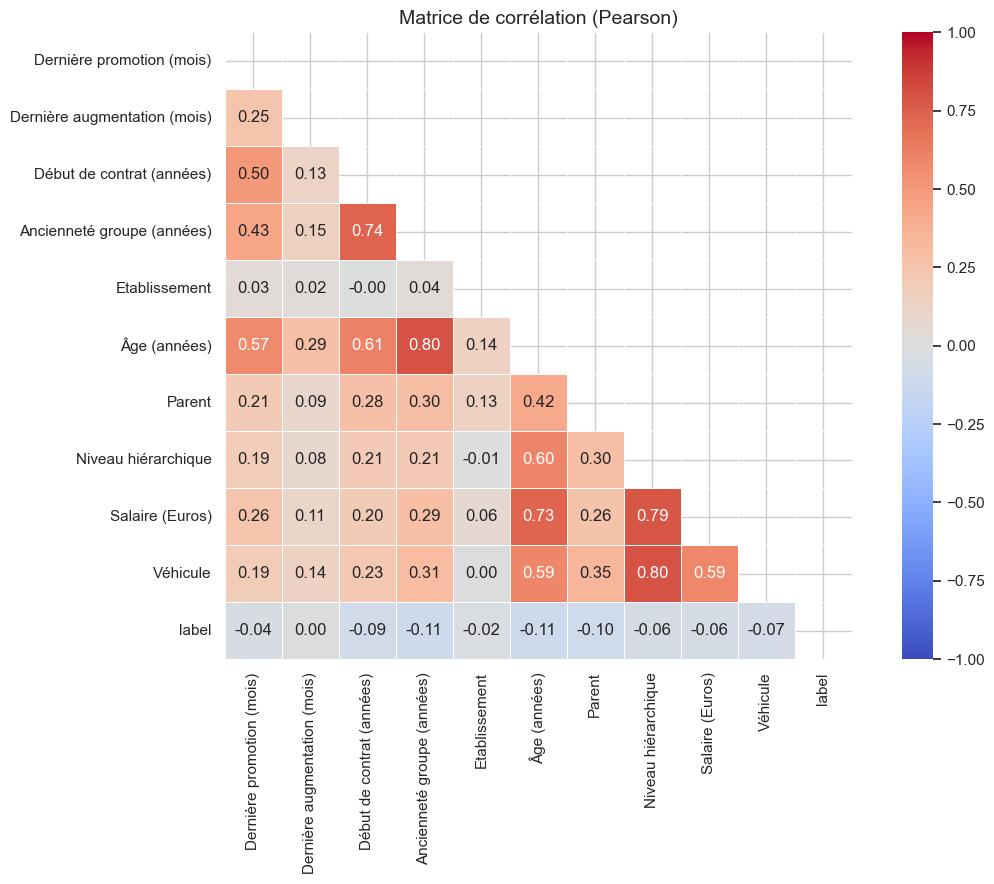

In [12]:
corr_cols = num_cols + ['label']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matrice de corrélation (Pearson)', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Corrélations avec le label, triées
corr_with_label = corr['label'].drop('label').sort_values(key=abs, ascending=False)
print('Corrélations avec le label (ordre décroissant) :')
print(corr_with_label.to_string())

Corrélations avec le label (ordre décroissant) :
Âge (années)                   -0.106636
Ancienneté groupe (années)     -0.105627
Parent                         -0.095071
Début de contrat (années)      -0.086285
Véhicule                       -0.065892
Salaire (Euros)                -0.058090
Niveau hiérarchique            -0.057757
Dernière promotion (mois)      -0.039810
Etablissement                  -0.024174
Dernière augmentation (mois)    0.003011


> **Commentaire :** La matrice de corrélation révèle plusieurs relations intéressantes. `Ancienneté groupe (années)` et `Début de contrat (années)` sont très fortement corrélées, ce qui est logique (plus un employé a commencé tôt, plus son ancienneté est grande) — l'une d'elles pourrait être supprimée pour éviter la multicolinéarité. `Salaire (Euros)` est lui aussi corrélé à l'ancienneté. Concernant le label, les corrélations restent faibles, ce qui indique que la prédiction nécessitera de combiner plusieurs variables plutôt que de se reposer sur une seule.

### 1.7 Analyses complémentaires

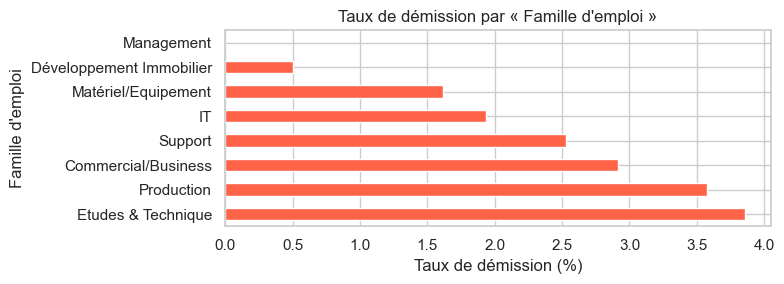

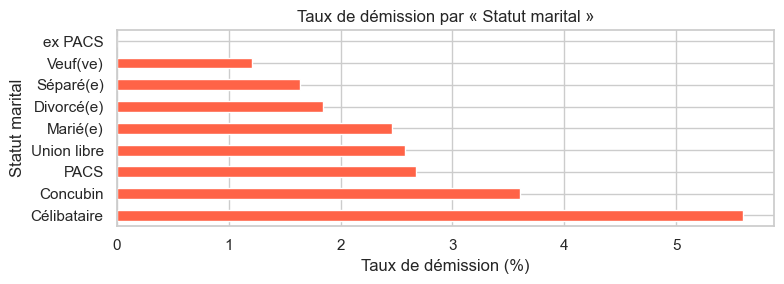

In [14]:
# Taux de démission par variable catégorielle
for col in cat_cols:
    taux = df.groupby(col)['label'].mean().sort_values(ascending=False) * 100
    fig, ax = plt.subplots(figsize=(8, 3))
    taux.plot(kind='barh', ax=ax, color='tomato')
    ax.set_xlabel('Taux de démission (%)')
    ax.set_title(f'Taux de démission par « {col} »')
    plt.tight_layout()
    plt.show()

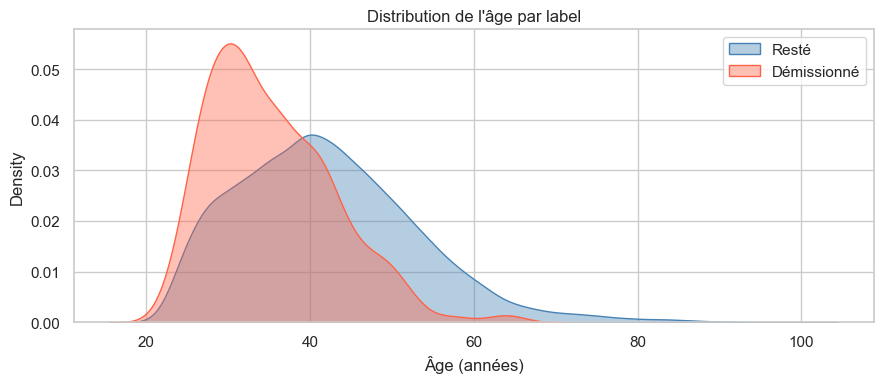

In [15]:
# Distribution de l'âge colorée par label
fig, ax = plt.subplots(figsize=(9, 4))
for label_val, color, name in [(0, 'steelblue', 'Resté'), (1, 'tomato', 'Démissionné')]:
    sns.kdeplot(df[df['label'] == label_val]['Âge (années)'], ax=ax,
                label=name, color=color, fill=True, alpha=0.4)
ax.set_title('Distribution de l\'âge par label')
ax.legend()
plt.tight_layout()
plt.show()

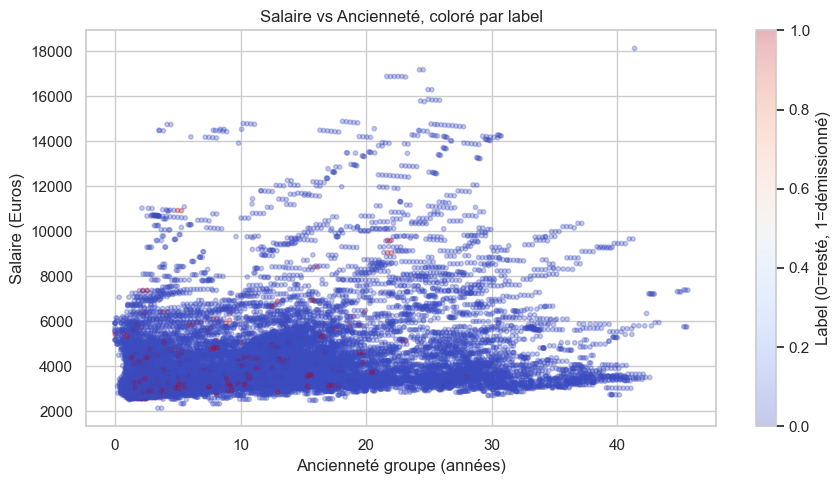

In [16]:
# Salaire vs Ancienneté, coloré par label
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    df['Ancienneté groupe (années)'], df['Salaire (Euros)'],
    c=df['label'], cmap='coolwarm', alpha=0.3, s=10
)
plt.colorbar(scatter, ax=ax, label='Label (0=resté, 1=démissionné)')
ax.set_xlabel('Ancienneté groupe (années)')
ax.set_ylabel('Salaire (Euros)')
ax.set_title('Salaire vs Ancienneté, coloré par label')
plt.tight_layout()
plt.show()

> **Commentaire :** Les taux de démission par catégorie mettent en évidence des disparités notables selon la famille d'emploi et l'établissement. Certains établissements ou métiers présentent des taux nettement plus élevés, ce qui suggère que ces variables auront un pouvoir prédictif important. La distribution de l'âge montre que les démissionnaires sont en moyenne plus jeunes. Le scatter Salaire vs Ancienneté confirme que les démissionnaires (en rouge) se concentrent dans les faibles niveaux de salaire, indépendamment de l'ancienneté.

---
## 2. Analyse des variables sensibles et biais potentiels

### 2.1 Identification des variables sensibles et proxies

Dans le contexte des RH et de l'IA responsable, une **variable sensible** est une variable dont l'utilisation dans un modèle prédictif pourrait conduire à une discrimination illégale ou éthiquement inacceptable (au sens du RGPD et de la législation anti-discrimination).

Un **proxy** est une variable corrélée à une caractéristique sensible, permettant d'inférer indirectement cette dernière.

| Variable | Type | Justification |
|---|---|---|
| **Âge (années)** | **Sensible directe** | L'âge est explicitement protégé par le droit du travail (discrimination par l'âge). |
| **Statut marital** | **Sensible directe** | Peut être corrélé au sexe (congé maternité/paternité) et à la situation familiale. |
| **Parent** | **Sensible / Proxy** | Variable binaire indiquant si l'employé est parent. Peut constituer un proxy pour le sexe (si les femmes sont sur-représentées parmi les parents qui démissionnent). |
| **Salaire (Euros)** | **Proxy potentiel** | Peut refléter des inégalités de genre ou d'origine. Corrélé à l'âge et à l'ancienneté. |
| **Etablissement** | **Proxy potentiel** | Peut être corrélé à la nationalité, l'origine géographique ou le niveau socio-économique. |
| **Famille d'emploi** | **Proxy potentiel** | Certains secteurs sont fortement genrés (ex. infirmier/infirmière) et pourraient révéler indirectement le sexe. |
| **Niveau hiérarchique** | **Proxy potentiel** | Peut refléter des discriminations systémiques liées au genre ou à l'origine. |
| **matricule** | **Identifiant** | Identifiant unique : doit être exclu des modèles pour éviter le surapprentissage et la réidentification. |

/var/folders/xt/dvtp1prj3pg6x4ybk7s2p4t00000gn/T/ipykernel_76432/2746285334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, palette=['steelblue', 'tomato'], ax=axes[i])
/var/folders/xt/dvtp1prj3pg6x4ybk7s2p4t00000gn/T/ipykernel_76432/2746285334.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Resté', 'Démissionné'])
/var/folders/xt/dvtp1prj3pg6x4ybk7s2p4t00000gn/T/ipykernel_76432/2746285334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col, palette=['steelblue', 'tomato'], ax=axes[i])
/var/folders/xt/dvtp1prj3pg6x4ybk7s2

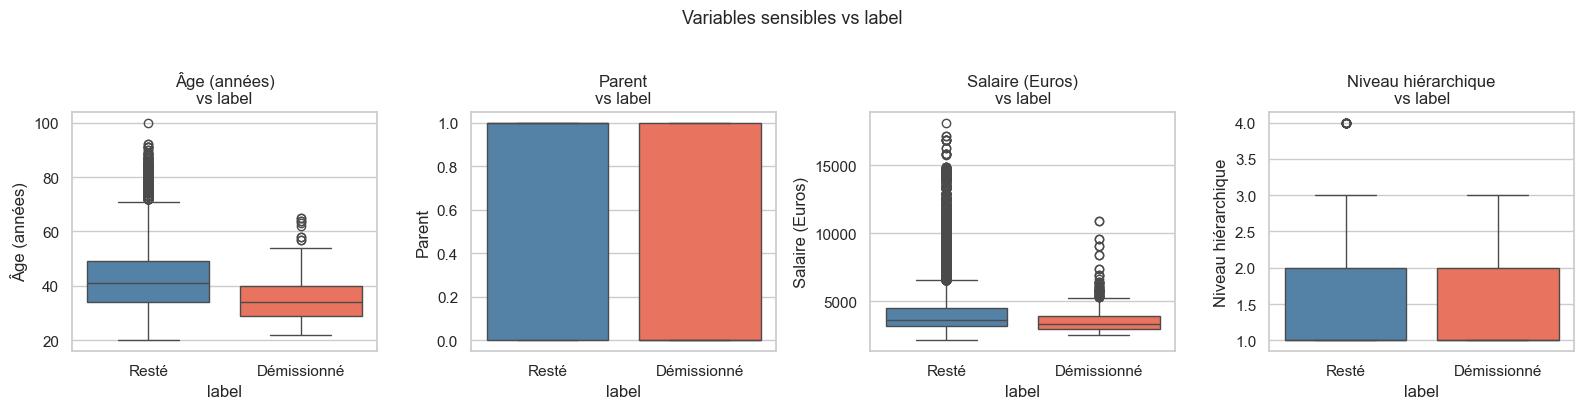

In [17]:
# Analyse de la corrélation entre variables sensibles et le label
sensitive_vars = ['Âge (années)', 'Parent', 'Salaire (Euros)', 'Niveau hiérarchique']

fig, axes = plt.subplots(1, len(sensitive_vars), figsize=(16, 4))
for i, col in enumerate(sensitive_vars):
    sns.boxplot(data=df, x='label', y=col, palette=['steelblue', 'tomato'], ax=axes[i])
    axes[i].set_title(f'{col}\nvs label')
    axes[i].set_xticklabels(['Resté', 'Démissionné'])
plt.suptitle('Variables sensibles vs label', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

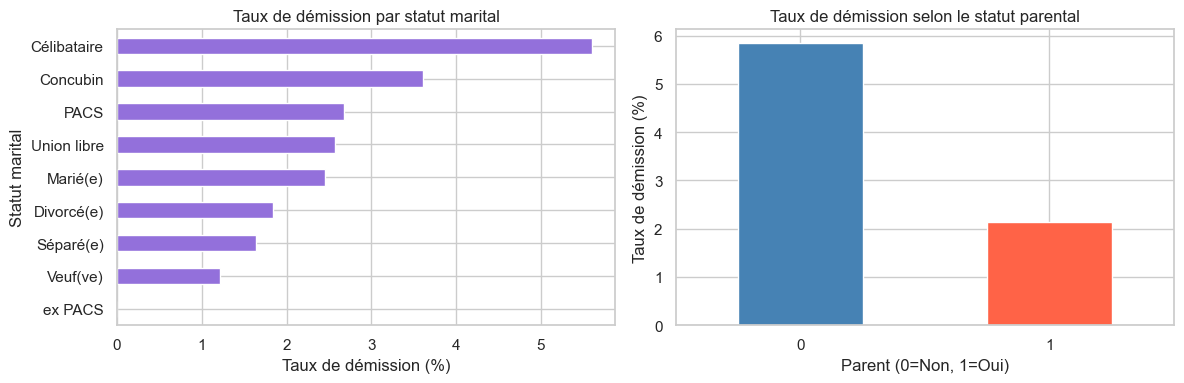

In [18]:
# Taux de démission par statut marital et statut parental
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

taux_marital = df.groupby('Statut marital')['label'].mean() * 100
taux_marital.sort_values().plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_xlabel('Taux de démission (%)')
axes[0].set_title('Taux de démission par statut marital')

taux_parent = df.groupby('Parent')['label'].mean() * 100
taux_parent.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_xlabel('Parent (0=Non, 1=Oui)')
axes[1].set_ylabel('Taux de démission (%)')
axes[1].set_title('Taux de démission selon le statut parental')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

> **Commentaire :** On observe effectivement des différences de taux de démission selon le statut marital et le statut parental. Par exemple, les employés célibataires semblent démissionner plus fréquemment. Ces écarts peuvent s'expliquer par des raisons légitimes (mobilité professionnelle plus élevée chez les jeunes non mariés), mais ils peuvent aussi révéler des biais systémiques. Si on inclut ces variables dans un modèle, le risque est qu'il discrimine indirectement en fonction de caractéristiques protégées liées au genre ou à la situation familiale.

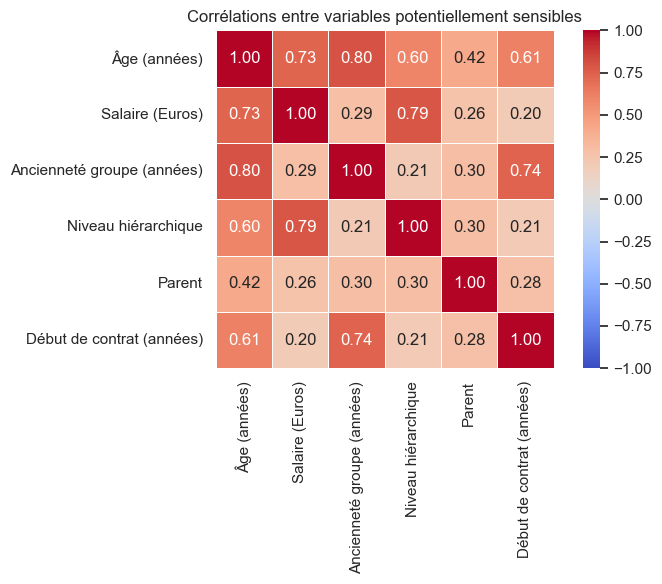

In [19]:
# Corrélation entre variables sensibles (pour détecter les proxies)
sensitive_and_num = [c for c in ['Âge (années)', 'Salaire (Euros)', 'Ancienneté groupe (années)',
                                   'Niveau hiérarchique', 'Parent', 'Début de contrat (années)'] if c in df.columns]

fig, ax = plt.subplots(figsize=(8, 6))
corr_sens = df[sensitive_and_num].corr()
sns.heatmap(corr_sens, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Corrélations entre variables potentiellement sensibles')
plt.tight_layout()
plt.show()

### 2.2 Synthèse et recommandations

**Variables à traiter avec précaution :**
- **`Âge (années)`** : directement sensible → envisager de la supprimer ou de mesurer l'impact sur l'équité du modèle.
- **`Statut marital`** et **`Parent`** : proxies potentiels → analyser les disparités de prédiction entre sous-groupes.
- **`Famille d'emploi`** : proxy de genre possible → surveiller les métriques de fairness par modalité.
- **`matricule`** : identifiant → **exclure obligatoirement** du modèle.

**Recommandations IA responsable :**
1. Exclure `matricule` des features.
2. Mesurer les métriques de fairness (parité démographique, égalité des chances) pour les variables sensibles.
3. Evaluer l'impact de la suppression des variables sensibles sur les performances du modèle (trade-off performance / équité).
4. Appliquer des techniques d'atténuation des biais si nécessaire (re-weighting, adversarial debiasing).

---
## 3. Apprentissage automatique *(à compléter lors de la prochaine séance)*

Cette section sera complétée lors de la prochaine séance de TP.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# Préparation des données
df_model = df.drop(columns=['matricule'])

X = df_model.drop(columns=['label'])
y = df_model['label']

cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape}, Test : {X_test.shape}')

Train : (19085, 12), Test : (4772, 12)


In [21]:
# Arbre de décision (interprétable)
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'))
])
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

print('=== Arbre de décision ===')
print(classification_report(y_test, y_pred_dt, target_names=['Resté (0)', 'Démissionné (1)']))
print(f'AUC-ROC : {roc_auc_score(y_test, dt_pipeline.predict_proba(X_test)[:, 1]):.4f}')

=== Arbre de décision ===
                 precision    recall  f1-score   support

      Resté (0)       0.99      0.62      0.76      4621
Démissionné (1)       0.06      0.72      0.11       151

       accuracy                           0.62      4772
      macro avg       0.52      0.67      0.43      4772
   weighted avg       0.96      0.62      0.74      4772

AUC-ROC : 0.7189


In [22]:
# Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10,
                                           random_state=42, class_weight='balanced', n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Resté (0)', 'Démissionné (1)']))
print(f'AUC-ROC : {roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:, 1]):.4f}')

=== Random Forest ===
                 precision    recall  f1-score   support

      Resté (0)       0.98      0.85      0.91      4621
Démissionné (1)       0.10      0.50      0.16       151

       accuracy                           0.84      4772
      macro avg       0.54      0.68      0.54      4772
   weighted avg       0.95      0.84      0.89      4772

AUC-ROC : 0.7709


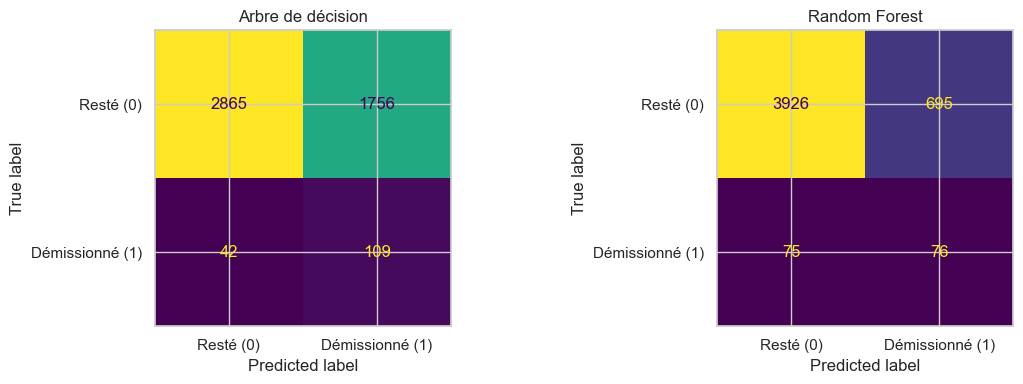

In [23]:
# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_dt, y_pred_rf],
    ['Arbre de décision', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Resté (0)', 'Démissionné (1)']).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

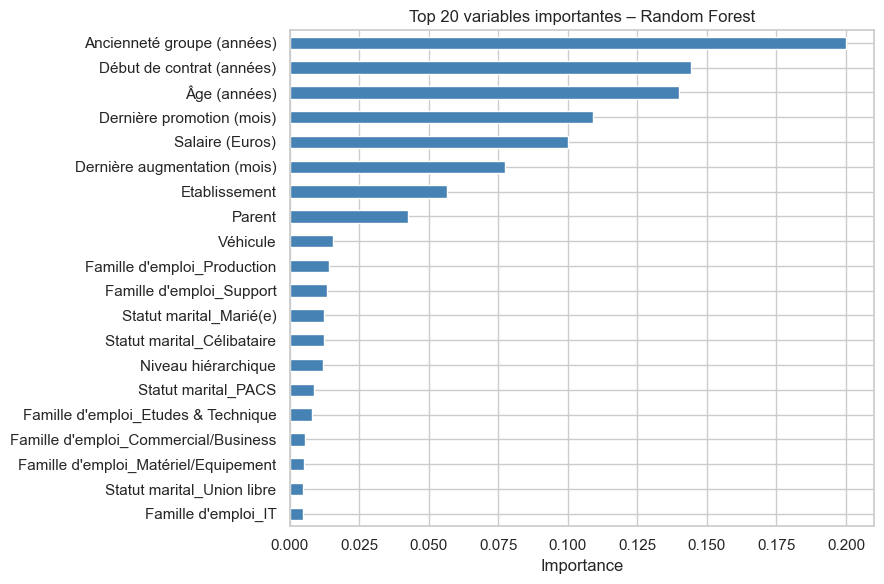

In [24]:
# Importance des variables (Random Forest)
rf_model = rf_pipeline.named_steps['classifier']
ohe_features = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features).tolist()
all_features = num_features + ohe_features

importances = pd.Series(rf_model.feature_importances_, index=all_features)
top_20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top_20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 variables importantes – Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

> **Commentaire :** Le graphique d'importance des variables confirme en partie nos observations exploratoires : les variables liées à l'ancienneté, au salaire et au délai depuis la dernière promotion ressortent parmi les plus déterminantes. On note également que certaines variables sensibles identifiées en Partie 2 (comme l'âge ou le statut parental) apparaissent dans le classement, ce qui soulève des questions d'équité. Une analyse SHAP permettrait d'aller plus loin en explicitant la contribution de chaque variable à chaque prédiction individuelle.